# **Tick Data**

*In this lesson, we will work directly with tick data, the most granular form of financial market information. We'll start with the basics: what tick data is, why it's called that, and why it's so important. Then, we'll get our hands dirty with real datasets, learning how to clean and process this high-resolution market information.
Why does this matter? Well, as financial markets become increasingly automated, understanding high-frequency data is becoming crucial for anyone serious about quantitative finance or algorithmic trading. We'll be working with actual tick data from cryptocurrency exchanges and stock markets. It is messy and challenging, but that's part of this workflow. By the end of this lesson, you'll have practical experience in handling this data, from cleaning it up to creating the time-aggregated charts you're probably more familiar with.*

## **1. What is Tick Data?**

In financial markets, data is the means that drives decision-making and trading strategies. Among the various types of market data available, tick data is the most granular and comprehensive. Tick data represents the most detailed record of trading activity, including every single transaction that occurs on an exchange. It includes the price, volume, and timestamp of each trade (and depending on the exchange or data vendor, there could be additional columns), allowing market participants to analyze market dynamics at the most fundamental level.

But why do we use the term "tick"?

The price of an asset seems to be a continuous variable. Indeed, in watching a plot of an asset someone can infer that the price can take any number between price point A and B. But this is not the case. The price is a discrete variable that moves in increments that are a product of a small increment called "tick".

Essentially, the word "tick" refers to the smallest price movement of an asset (stock, commodity, or futures) and it can be different for the same asset across exchanges and brokers (Harris). For example, if the tick size of a stock is \\$0.01 and the price of the stock is \\$100, the price can only be $100 + \lambda * 0.01$ with $\lambda \in \mathbb{Z}$. We can have prices of \\$100.01 or \\$100.15 but never \\$100.005.

Historically, the term "tick" originates from the sound of the early stock ticker machines of the late 19th century, which printed stock prices on a ticker tape.


**Crash of 1929 Ticker Tape**

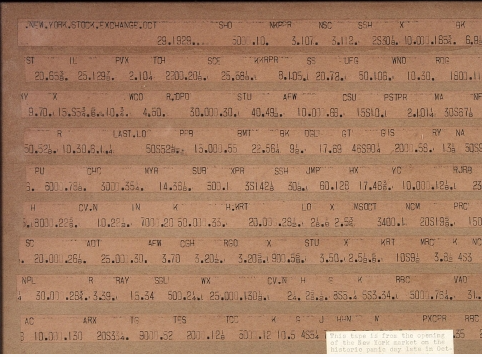

*As stock ticker machines recorded the stock prices, each transaction was accompanied by a ticking sound.*

Adapted from: Museum of American Finance. "Crash of 1929 Ticker Tape." https://www.moaf.org/publications-collections/museum-collection/objects/crash-1929-ticker-tape

"Tick data" is known by many names, each unveiling its important characteristics:

* **Tick-by-tick data**: Each point is a tick.

* **(Ultra) High-Frequency data**: The frequency of the ticks and the volume traded are very high, especially in liquid markets.

* **Trades**: Each tick represents a trade.

* **Transactions**: Each trade is a transaction between two parties.

* **Real-time data**: This data can be delivered in real-time with minimal latency.

Tick data not only includes trade data but may also include quote data. This data is known as a limit order book. So, if a market maker raised the AMOUNT they were willing to buy and placed an order at the bid side, there would be an additional observation that changes the bid size.

Likewise, if a market maker raised the bid price (the price where they were willing to buy), that would be an additional observation. Even if there were no trades, limit order book data is a rich source of information that contains the intentions of participants. As you will see in Figure 7, the intentions (new bids, asks, cancellations, etc.) change faster than the actions (actual trades) of the participants.

By now, you might have already some exposure to financial data. Most people have seen candlestick charts and price charts with a fixed time interval on the $x$-axis. There are online applications such as TradingView or Yahoo Finance and many online exchanges where one can plot the stock of their choice at any fixed time interval and even use their favorite indicators. Essentially, what you see is a structured dataset created after some people/code behind the scenes have acquired the tick data and produced the time bars.

The purpose of this lesson is not only to introduce tick data to students, showing how the data looks when it is first produced, but also to guide you in creating and plotting the structured datasets that you have been using until now. By doing so, we will transition from production (tick data) to consumption-ready datasets, similar to those that will be used in later courses for modeling and analysis.

It should be clear by now that tick data (and even more so the high-frequency order book) consists of the most granular data you can find. Being somewhat naive, one could say that this is all the data that is produced as trading goes on, and therefore, we can expect that it contains all the possible information. On the other hand, someone could argue that there are many external factors such as macroeconomic trends, sentiment, regulations, news, and more. However, if you are a believer in the efficient market hypothesis, then you should expect that any external factor will be priced in immediately. Thus, the external information becomes part of the price and the trading data in general, as soon as it becomes known.

Since tick data can be delivered in real-time, traders who analyze this data instead of minute, hourly, or daily time bars (which will incorporate the information in one minute, one hour, or a day, respectively) should be able to extract the information before the rest of the participants. These traders, though, face a very difficult task: separating information from noise.

For the purposes of this lesson, we chose three different high-frequency datasets. Two of them consist of tick-by-tick trade data, and the third one is Level 1 data mixed with trades. The choice of the assets is random and mostly affected by the availability of such data. Almost always, the high-frequency data is not given for free and is rather expensive. This is normal considering the vast amount of data produced daily and the technical difficulties of storing and distributing it.

For this reason, we will be exploring:

1.) BTC/USDT tick-by-tick trades downloaded from Kraken exchange: https://support.kraken.com/hc/en-us/articles/360047543791-Downloadable-historical-market-data-time-and-sales-

2.) RVN/USDT tick-by-tick trades downloaded from Binance exchange: https://data.binance.vision/

3.) AGLJ/ZAR Level 1 Data with trades downloaded from:  https://data.mendeley.com/datasets/4rrk89c3b2/2

Due to VM restrictions, a very small portion of the data above is sampled for teaching purposes. But you are encouraged to download large tick-by-tick datasets locally in order to face firsthand the technical difficulties of dealing with big data.

Tick-by-tick trade data consists of the following columns:

* Symbol: the unique identifier of the financial instrument.

* Timestamp: the exact time when the transaction was recorded (granularity ranges from second to nanosecond).

* Price: the executed price of the trade.

* Volume: The number of units traded.

* Trade Direction (optional): indicates whether the trade was buyer-initiated or seller-initiated.


The most important aspect of tick data, which is granularity, allows us to undertake:

* Studying intraday volatility.

* Understanding price formation more thoroughly.

* Backtesting of high-frequency (HF) trading strategies.

* Assessing market impact to determine scaling a strategy.

* Analyzing the transaction costs of a strategy.

* Exploring execution strategies.

* Detecting market manipulation (can be used by regulatory authorities).

* Aggregation to time-based or volume-based bars.

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

In [29]:
# Load the data, dataset (1) - BTC/USD from Kraken
btc_usdt = pd.read_csv("datasets/XBTUSDT.csv", names=['UNIX_time', 'price', 'volume'])
btc_usdt.head()

,UNIX_time,price,volume
0,1688169604,30474.1,0.018800
1,1688169604,30474.8,0.000103
2,1688169604,30476.5,0.014997
3,1688169656,30483.5,0.000614
4,1688170008,30479.0,0.000328


The dataset above is an example of a tick-by-tick trades dataset, and it consists of all the trades that occurred in a specified interval. The first thing that you notice is the UNIX_time column, which does resemble time or date! This timestamp is called "UNIX time," and it counts the number of time units (seconds, milliseconds, microseconds, and nanoseconds) from 00:00:00 UTC January 1, 1970, until now.

This time representation provides:

* Standardization: universal representation of time.

* Simplicity: it is a single integer.

* Efficiency: calculations are straightforward and computationally efficient.

The Unix Timestamps can be represented with different levels of precision:

* 10 digits: Represents seconds (e.g., 1688169604).

* 13 digits: Includes milliseconds (e.g., 1688169604123).

* 16 digits: Includes microseconds (e.g., 1688169604123456).

* 19 digits: Includes nanoseconds (e.g., 1688169604123456789).

You can also check [this](https://unixtime.org/) website.

In the dataset (1), we can count 10 digits for the UNIX_time column. Therefore, the precision is given in seconds, and this is the only thing we need to know in order to transform Unix time into human-readable datetime.

In [30]:
# Convert the UNIX timestamp to human readable datetime. Check the argument unit='s' to make sure the timestamp is in seconds.
btc_usdt['timestamp'] = pd.to_datetime(btc_usdt['UNIX_time'], unit='s')
btc_usdt.set_index('timestamp', inplace=True) # Set the timestamp as the index
btc_usdt.head()

,UNIX_time,price,volume
timestamp,,,
2023-07-01 00:00:04,1688169604,30474.1,0.018800
2023-07-01 00:00:04,1688169604,30474.8,0.000103
2023-07-01 00:00:04,1688169604,30476.5,0.014997
2023-07-01 00:00:56,1688169656,30483.5,0.000614
2023-07-01 00:06:48,1688170008,30479.0,0.000328


## **3. Visualizing Tick Trade Data**
Now, let's examine our dataset visually. Visualizing tick data presents unique challenges due to its extremely high resolution. Consider this analogy: imagine you have an ultra-high-resolution image displayed on a small screen or viewed from a distance. Much of the detail is lost, and you might wonder about the value of such high resolution. Similarly, when plotting tick data, we risk obscuring important patterns if we simply plot every point. The key is to find ways to represent this high-frequency data that reveal its inherent patterns and characteristics without overwhelming the viewer. In this section, our data is sourced from Gebbie and Nonyane's “TRTH JSE AGLJ.J Intraday Transaction Test Data" and from the datasets mentioned in section 2.

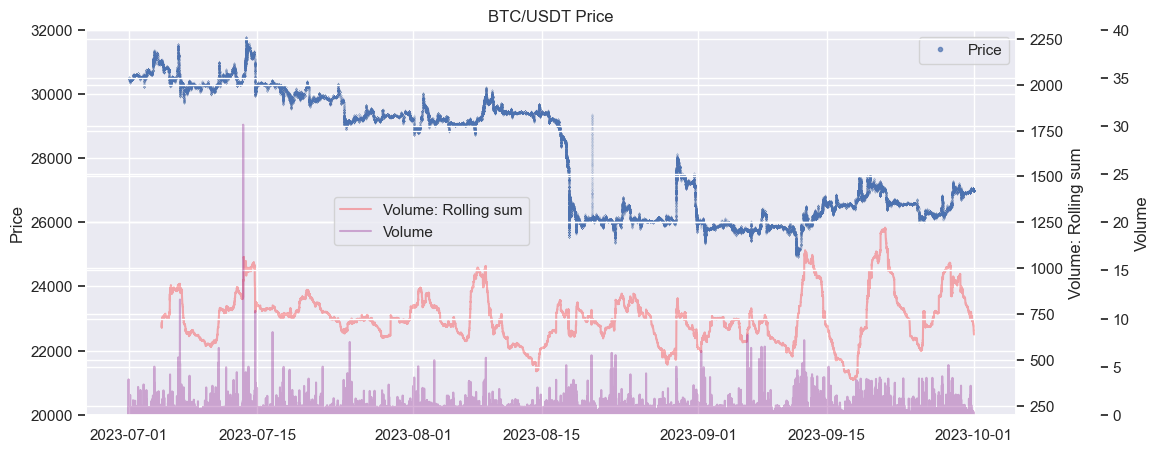

In [31]:
#Figure 1
fig, ax = plt.subplots(figsize=(12, 5))
ax.scatter(btc_usdt.index, btc_usdt['price'], s = 0.001, alpha=0.4)
ax.set_ylabel('Price')
ax.set_title('BTC/USDT Price')
ax.set_ylim(20000, 32000)

custom_legend = plt.Line2D([0], [0], linestyle="none", marker='o', color='b', markersize=3, alpha = 0.7, label='Price') # Creating a custom legend
ax.legend(handles=[custom_legend], loc='upper right')

ax2 = ax.twinx() # Create a second y-axis
ax2.plot(btc_usdt.index, btc_usdt['volume'].rolling(10000).sum(), color='red', label='Volume: Rolling sum', alpha=0.3)
ax2.set_ylabel('Volume: Rolling sum')
ax2.set_ylim(200, 2300)

ax3 = ax.twinx() # Create a third y-axis
ax3.plot(btc_usdt.index, btc_usdt['volume'], color='purple', label='Volume', alpha=0.3)
ax3.set_ylabel('Volume')
ax3.set_ylim(0, 40)
ax3.spines['right'].set_position(('outward', 60))

fig.legend(bbox_to_anchor=(0.5,0.56)) # Adjust the legend position
plt.show()

We must note that datasets (1) and (2) are retrieved directly from the exchanges where they were produced; thus, we expect no missing inputs. That does not mean there are no errors in the data!

Let's explore our dataset:

In [32]:
between_trades_interval = btc_usdt['UNIX_time'].diff().dropna() # Calculate the trade duration
print("Summary Statistics \n\n", between_trades_interval.describe(), "\n\n") # Get the summary statistics of the trade duration
print("10 Largest trade durations \n\n", between_trades_interval.sort_values(ascending=False).head(10)) # Get the top 10 largest durations between trades

Summary Statistics 

 count    358309.000000
mean         22.184026
std          55.319270
min           0.000000
25%           0.000000
50%           0.000000
75%          20.000000
max        2195.000000
Name: UNIX_time, dtype: float64 


10 Largest trade durations 

 timestamp
2023-08-01 15:41:45    2195.0
2023-07-12 09:19:13    2001.0
2023-08-17 10:30:32    1809.0
2023-08-18 15:05:14    1576.0
2023-07-23 07:29:23    1281.0
2023-07-23 02:13:51    1244.0
2023-08-06 03:40:46    1224.0
2023-09-28 15:28:56    1177.0
2023-07-20 23:44:23    1125.0
2023-07-16 03:52:08    1113.0
Name: UNIX_time, dtype: float64


Judging from the above results (high trade durations), the pair BTC/USDT in the specific sample seems to be illiquid. But we know that liquidity can vary greatly over time and this sample may not be representative of this pair's liquidity on this exchange. To draw more robust conclusions, we would need to analyze a larger dataset spanning different time periods and market conditions.

Let's check the distribution of volume, simple returns and intervals between trades.

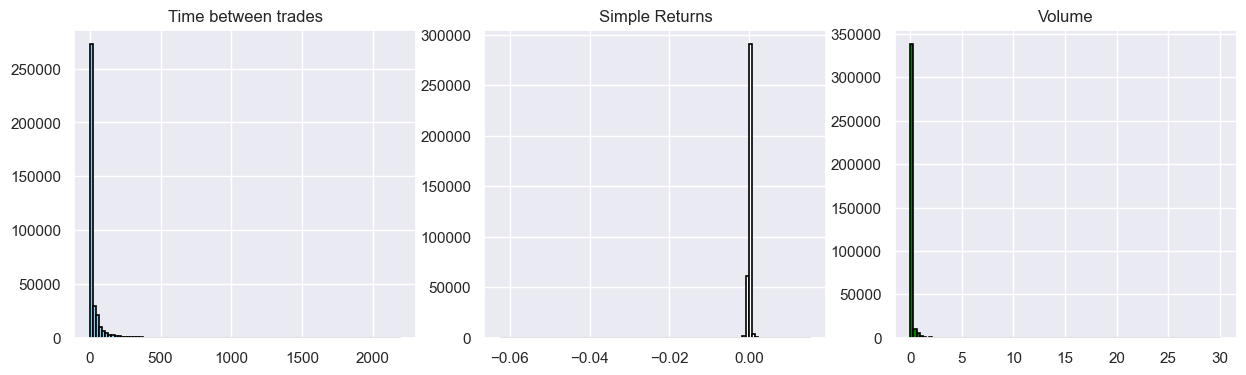

In [33]:
#Figure 2
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))
ax1.hist(between_trades_interval, bins=100, color='skyblue', edgecolor='black', linewidth=1.2)
ax1.set_title("Time between trades")
ax2.hist(btc_usdt['price'].pct_change().dropna(), bins=100, color='white', edgecolor='black', linewidth=1.2)
ax2.set_title("Simple Returns")
ax3.hist(btc_usdt['volume'], bins=100, color='green', edgecolor='black', linewidth=1.2)
ax3.set_title("Volume")
plt.show()

The above results hint at three important facts:

* There are several trades that happened at the same second. Those trades could be a single trade that was divided in many trades at the moment of execution as the volume at the best bid or ask was not enough to cover the trade volume in that instant. These trades are called **split transactions**.

* There are several trades that did not result in a price change.

* A lot of trades seem to have very low volume.

In [34]:
boolean_array_is_duplicate = btc_usdt['UNIX_time'].duplicated(keep=False) # Check for duplicates
sum_of_duplicates = boolean_array_is_duplicate.sum() # Sum the duplicates
print("The number of trades that occured at the same second with at least one more trade, is: ",sum_of_duplicates)
print("The percentage of these trades to the number of all trades, is: ",round(sum_of_duplicates / len(btc_usdt) * 100, 2), "%")
print("The percentage of the volume of these trades to the entire volume, is: ",round(((boolean_array_is_duplicate * btc_usdt['volume']).sum() / btc_usdt['volume'].sum() )* 100, 2), "%")

The number of trades that occured at the same second with at least one more trade, is:  241814
The percentage of these trades to the number of all trades, is:  67.49 %
The percentage of the volume of these trades to the entire volume, is:  90.44 %


We will assume that these trades are split transactions. After some simple aggregations, the histograms plotted above look very different:

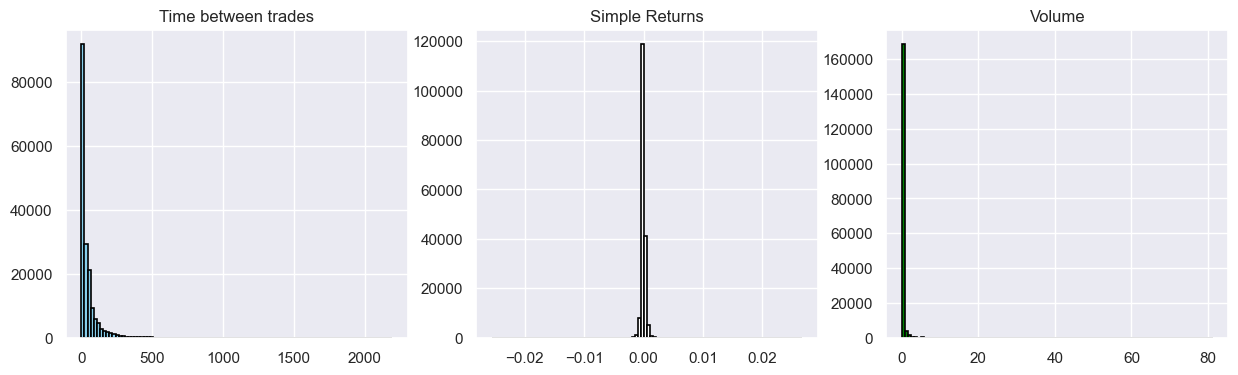

In [35]:
# Figure 3
aggr_dataset_1 = pd.DataFrame()
aggr_dataset_1['UNIX_time'] = btc_usdt['UNIX_time'].groupby(btc_usdt['UNIX_time']).first() # Group the UNIX timestamp by the first timestamp
aggr_dataset_1['volume'] = btc_usdt['volume'].groupby(btc_usdt['UNIX_time']).sum() # Aggregate the volume by the UNIX timestamp
aggr_dataset_1['price'] = (btc_usdt['price'] * btc_usdt['volume']).groupby(btc_usdt['UNIX_time']).sum() / aggr_dataset_1['volume'] # Final price as VWAP of the split transaction
aggr_dataset_1.index = btc_usdt.index.drop_duplicates() # Drop the duplicates from the index

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))
ax1.hist(aggr_dataset_1['UNIX_time'].diff().dropna(), bins=100, color='skyblue', edgecolor='black', linewidth=1.2)
ax1.set_title("Time between trades")
ax2.hist(aggr_dataset_1['price'].pct_change().dropna(),bins=100, color='white', edgecolor='black', linewidth=1.2)
ax2.set_title("Simple Returns")
ax3.hist(aggr_dataset_1['volume'], bins=100, color='green', edgecolor='black', linewidth=1.2)
ax3.set_title("Volume")
plt.show()

At this point, one could continue the workflow with a returns analysis, an order flow imbalance (OFI), volatility estimation, liquidity measure, etc. Since these datasets will be used for tick-data presentation and not analysis, we will move to dataset (2), and an introductory workflow will be presented with dataset (3).

## **4. Including the Trade Direction**

Let's check dataset (2), which holds the RVN/USDT trades but with one addition to the dataset (1): there is an additional column, "Trade Direction," which holds information on whether the trader who initiated the trade was a buyer or a seller. In our case, the exchange is storing a boolean value (True, False) for each row that answers the question *is the buyer the market maker?*

As we know, for each transaction, there must be a buyer and a seller. If the answer to the above question is true, then the market maker placed a bid order in the orderbook with the intention to buy, and a seller initiated the trade (partially?) filling that buying order. If, on the other hand, the answer is false, then the market maker was a seller who placed an ask order. In this case, the initiator of the trade is a buyer who filled that specific ask order.

This additional boolean array is a source of valuable information.

We will begin by loading dataset (2). In many cases, the data vendor/exchange will let you download the data in `csv` files with each file containing the data of one day (or week, or month, or custom interval). In our case, dataset (2) consists of four daily files. We will be using the `glob` library due to its simplicity in selecting the files we need: https://builtin.com/software-engineering-perspectives/glob-in-python.

In [36]:
import glob

# Load the data, dataset (2) - RVN/USDT
list_of_files = glob.glob('datasets/RVNUSDT*') # List the RVNUSDT files in the directory
column_names = ['id', 'price', 'qty', 'base_qty', 'UNIX_time', 'is_buyer_maker', 'is_best_match'] # Column names
rvn_usdt = pd.concat([pd.read_csv(file, names=column_names) for file in list_of_files], ignore_index=True, axis = 0) # Concatenate the files
rvn_usdt.sort_values('UNIX_time', inplace=True) # Sort the values by time
rvn_usdt.head(5)

,id,price,qty,base_qty,UNIX_time,is_buyer_maker,is_best_match
0,54407520,0.02588,424.9,10.996412,1680307215745,False,True
1,54407521,0.02588,3313.5,85.753380,1680307215759,False,True
2,54407522,0.02588,4172.5,107.984300,1680307215759,False,True
3,54407523,0.02588,5162.5,133.605500,1680307215762,False,True
4,54407524,0.02588,1041.3,26.948844,1680307215762,False,True


Let's step back for a moment. Dataset (2) is a tick-by-tick trades dataset, but there are twice as many columns as in dataset (1). At this point, it must be clear that depending on the data vendor and/or the exchange, there could be additional columns to the three basic ones (price, volume, and timestamp). In our case, the only meaningful addition to the basic columns is the `is_buyer_maker` column.

The `base_qty` represents the volume of the base currency (the currency that the asset is traded against) traded given the volume of the asset traded and the price of the trade $\text{ base_qty } = \text{ qty } * \text{ price }$. The column `id` represents the id of each trade and can be used to filter out duplicate entries. Lastly, the column `is_best_match` is a boolean array that indicates whether the trade was executed at the best possible price given the orderbook at that time (True or False).

We will check whether the additional columns hold any information before we omit them in order to handle a smaller dataset, which will be less taxing on ram.

In [37]:
print("Number of duplicate entries: ", rvn_usdt['id'].duplicated().sum()) # Check for duplicates
print("Number of entries that were not executed at the best possible price: ", (~rvn_usdt['is_best_match']).sum()) # Check for best match
print("Can the base_qty be derived from the qty and price?: ", np.isclose(rvn_usdt['price'] * rvn_usdt['qty'], rvn_usdt['base_qty'], atol=1e-05).all()) # Check if the base quantity can be derived from the quantity
print("Due to the results above, we can drop the columns 'id', 'is_best_match' and 'base_qty' \n\n")

rvn_usdt = rvn_usdt.drop(columns=['id', 'is_best_match', 'base_qty']) # Drop the unnecessary columns
rvn_usdt['timestamp'] = pd.to_datetime(rvn_usdt['UNIX_time'], unit='ms') # Convert the UNIX timestamp to human readable datetime. Check the argument unit='ms' to make sure the timestamp is in milliseconds.
rvn_usdt.set_index('timestamp', inplace=True) # Set the timestamp as the index
rvn_usdt.head()

Number of duplicate entries:  0
Number of entries that were not executed at the best possible price:  0
Can the base_qty be derived from the qty and price?:  True
Due to the results above, we can drop the columns 'id', 'is_best_match' and 'base_qty' 




,price,qty,UNIX_time,is_buyer_maker
timestamp,,,,
2023-04-01 00:00:15.745,0.02588,424.9,1680307215745,False
2023-04-01 00:00:15.759,0.02588,3313.5,1680307215759,False
2023-04-01 00:00:15.759,0.02588,4172.5,1680307215759,False
2023-04-01 00:00:15.762,0.02588,5162.5,1680307215762,False
2023-04-01 00:00:15.762,0.02588,1041.3,1680307215762,False


## **5. Manipulating Tick Data**

From now and on, with "buying volume" or "selling volume," we will refer to the volume of the trades whose initiator/taker was the buyer or seller, respectively. To understand how to use the added information, we will present the data manipulations that are essential for calculating the buying and selling volume.

The buying volume is:  6081743642.6
The selling volume is:  6530522239.799997


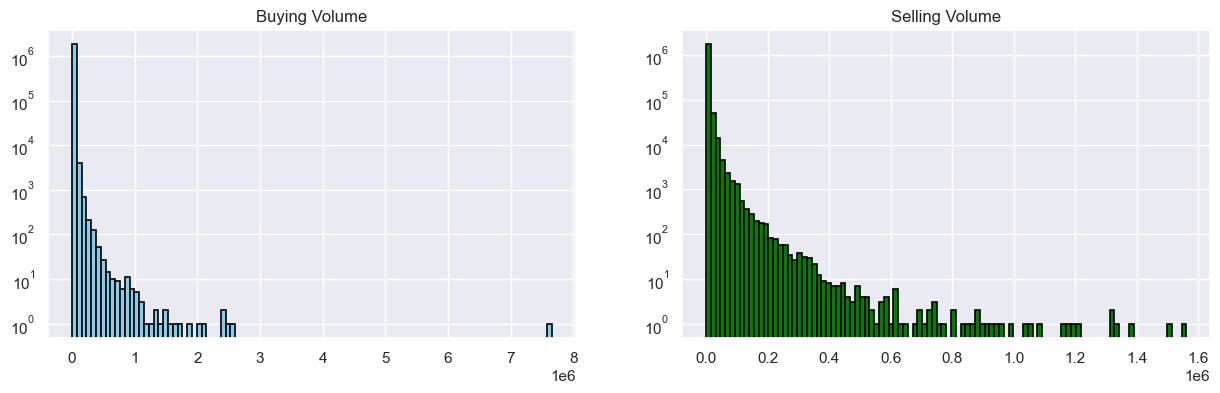

In [38]:
# Figure 4
buying_volume = rvn_usdt['qty'] * (~rvn_usdt['is_buyer_maker']) # An array that contains the buying volume
selling_volume = rvn_usdt['qty'] * rvn_usdt['is_buyer_maker'] # An array that contains the selling volume

print("The buying volume is: ", buying_volume.sum()) # Calculate the buying volume
print("The selling volume is: ", selling_volume.sum()) # Calculate the selling volume

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4))
ax1.hist(buying_volume, log = True, bins=100, color='skyblue', edgecolor='black', linewidth=1.2)
ax1.set_title("Buying Volume")
ax2.hist(selling_volume, log = True, bins=100, color='green', edgecolor='black', linewidth=1.2)
ax2.set_title("Selling Volume")
plt.show()

**Exercise 1**

In the histogram above, we have used the argument `log = True` in order to transform the $y$ axis in log scale. To see why, plot the histograms of the buying and selling volume with `log = False`. Furthermore, let's distinguish between transforming the $y$ axis for visualization purposes and transforming the data itself, using the natural logarithm. Create the two histograms again with `log = False`, but use the `np.log` function to transform the buying and selling volume: `np.log(buying_volume[buying_volume > 1])`. Do the same for the histograms presented in Figure 3. Explain the differences.

**Exercise 2**

Calculate the tick size for datasets (1) and (2). Explain your methodology in the forum.

We will now plot the buying and selling volume in a visually pleasing way. When plotting high resolution data, it makes no sense to zoom out in order to see the "big picture." On the contrary, we opt for zoomed-in graphs or interactive plots (plotly, bokeh) where we can zoom in on demand.

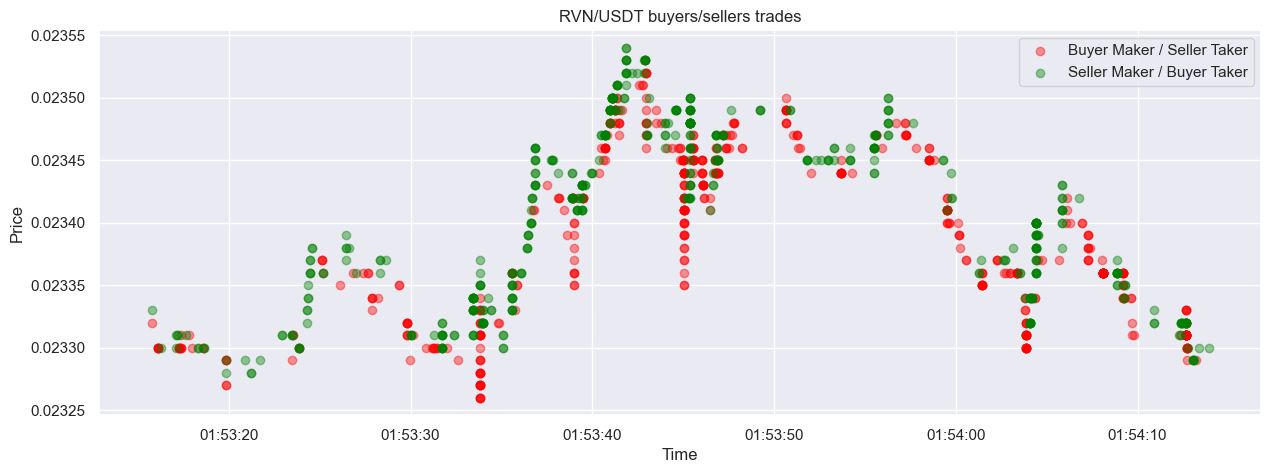

In [39]:
# Figure 5
rvn_usdt_slice = rvn_usdt.loc['2023-07-01 01:53:15.745':'2023-07-01 01:54:15.745'] # Slice the data

fig, ax = plt.subplots(figsize=(15, 5))

ax.scatter(x = rvn_usdt_slice[rvn_usdt_slice['is_buyer_maker'] == True].index, \
           y = rvn_usdt_slice[rvn_usdt_slice['is_buyer_maker'] == True]['price'], color='red', \
            label='Buyer Maker / Seller Taker', alpha = 0.4) # Plot the buyer maker / seller taker
ax.scatter(x = rvn_usdt_slice[rvn_usdt_slice['is_buyer_maker'] == False].index, \
           y = rvn_usdt_slice[rvn_usdt_slice['is_buyer_maker'] == False]['price'], color='green', \
            label='Seller Maker / Buyer Taker', alpha = 0.4) # Plot the seller maker / buyer taker
ax.set_title("RVN/USDT buyers/sellers trades")
ax.set_xlabel("Time")
ax.set_ylabel("Price")
ax.legend()
plt.show()

**Exercise 3**

In Figure 5, we can see a zoomed-in graph of the RVN/USDT buyers' and sellers' trades. The interval chosen is exactly 1 minute. In this exercise, you must recreate Figure 5 for different intervals. You can choose larger intervals and/or different points in time. In order to have a guide in choosing the intervals that **interest** you, you will have to plot the entire price plot of the RVN/USDT pair.

**Exercise 4** *(Optional)*

Using the code provided in this notebook as a guide, download the tick data locally in order to continue your workflow on your own PC. Then, try to use plotly or bokeh (holoviews) in order to create the interactive plots that will let you zoom in without slicing the dataset every time you want to create a new graph. Check [here](https://plotly.com/python/) for the gallery provided by plotly, and make sure you understand the difference between an interactive plot and a static one.

## **6. Level 1 Data (L1)**

Level 1 data (or else top-of-book data (TOB)) typically include the following columns:

* Symbol: the unique identifier of the financial instrument.

* Timestamp: the exact time when the event was recorded.

* Bid price: the highest price a buyer is willing to pay.

* Ask price: the lowest price a seller is willing to accept.

* Ask volume: number of units available at the ask price.

* Bid Volume: number of units available at the bid price.

In [40]:
# Load the data, dataset (3) - AGLJ_J
columns = ['RIC', 'DateTimeL', 'Type', 'Price', 'Volume', 'L1 Bid', 'L1 Ask', 'Trade Sign']
aglj = pd.read_csv('datasets/AGLJ_J_04-Jan-2016_TO_10-May-2016_5days.csv', \
                   names = columns, skiprows = 1) # Load the data
aglj.sort_values(by = 'DateTimeL', inplace = True)
aglj.head(5)

,RIC,DateTimeL,Type,Price,Volume,L1 Bid,L1 Ask,Trade Sign
1,AGLJ.J,736333.382013,Quote,0.0,0.0,0.0,6800.0,0
0,AGLJ.J,736333.382013,Trade,6750.0,366.0,0.0,0.0,0
4,AGLJ.J,736333.382015,Quote,0.0,0.0,6735.0,6800.0,0
3,AGLJ.J,736333.382015,Quote,0.0,0.0,0.0,6800.0,0
2,AGLJ.J,736333.382015,Trade,6750.0,374.0,0.0,0.0,0


The first thing to notice is the `DateTimeL` column. This is another format you may encounter when using tick data, and it represents a *serial date* number expressing dates and times. Specifically, it counts the number of days from a given date, which is called `base_date`. In our case, the `base_date` is January 1, 0000. For example, the 736333.382013 translates to the 736333rd day since January 1, 0000. The decimal part, represents the fraction of the day. In our example the 736333rd day is January 4, 2016, and the fraction 0.382013 corresponds to 09:10:05.

With the help of the `datetime` Python library, we will transform the serial date to a human-readable one. But this is not without problems! The `datetime` library calendar begins from Jan 1, 0001, as historically, there is no year 0000. On the other hand, indexing from 0 is preferred for scientific calculations. Students need not go deep into this matter, but this is a good example of the different notations that one faces when dealing with tick data.

In [41]:
from datetime import datetime, timedelta

def convert_serial_to_datetime(serial):
    # Define the base date as January 1, 0001
    base_date = datetime(1, 1, 1)

    # Split the serial date into days and fractional days
    days = int(serial)
    fractional_day = serial - days

    # Adjust for the lack of year 0 by subtracting 367 days
    adjusted_days = days - 367

    # Calculate the target date by adding the adjusted days and fractional day (converted to seconds) to the base date
    target_date = base_date + timedelta(days=adjusted_days) + timedelta(seconds=fractional_day * 86400)

    # Return the target date in human-readable format
    return target_date.strftime('%Y-%m-%d %H:%M:%S')

aglj['timestamp'] = aglj['DateTimeL'].apply(convert_serial_to_datetime) # Convert the serial date to human readable datetime
aglj['timestamp'] = pd.to_datetime(aglj['timestamp']) # Convert the timestamp to datetime object
aglj.set_index('timestamp', inplace=True) # Set the timestamp as the index
aglj.head(5)

,RIC,DateTimeL,Type,Price,Volume,L1 Bid,L1 Ask,Trade Sign
timestamp,,,,,,,,
2016-01-04 09:10:05,AGLJ.J,736333.382013,Quote,0.0,0.0,0.0,6800.0,0
2016-01-04 09:10:05,AGLJ.J,736333.382013,Trade,6750.0,366.0,0.0,0.0,0
2016-01-04 09:10:06,AGLJ.J,736333.382015,Quote,0.0,0.0,6735.0,6800.0,0
2016-01-04 09:10:06,AGLJ.J,736333.382015,Quote,0.0,0.0,0.0,6800.0,0
2016-01-04 09:10:06,AGLJ.J,736333.382015,Trade,6750.0,374.0,0.0,0.0,0


Let's now apply some cleaning filters:

Before we can effectively analyze high-frequency financial data, it's crucial to clean and preprocess the dataset. This cleaning process helps to remove erroneous entries and adjust for certain market microstructure effects, ensuring that our subsequent analyses are based on accurate and meaningful data.

First, we remove entries with zero or negative prices, quotes, or volumes. These are likely data errors, as prices and volumes in financial markets should always be positive. Negative spreads (where the bid price exceeds the ask price) are also eliminated as they represent impossible market conditions under normal circumstances.

Next, we address the issue of split transactions. In high-frequency trading, a single large order may be executed as multiple smaller trades at the same timestamp. This can lead to an overrepresentation of certain price levels and potentially skew our analysis. To mitigate this, we aggregate trades occurring at the same timestamp, summing their volumes and calculating a volume-weighted average price (VWAP). This approach preserves overall trading information while avoiding the artificial inflation of trade counts.
Similarly, we deal with intra-second quotes by keeping only the last quote for each timestamp. This is because, in a fast-moving market, the most recent quote is typically the most relevant for analysis.

In [42]:
# Delete entries with a quote or transaction price equal to zero of being negative
prices = aglj[aglj['Type'] == ' Trade']['Price'] # Get the transaction prices
quotes = aglj[aglj['Type'] == ' Quote'][['L1 Bid', 'L1 Ask']] # Get the quotes
print("Number of entries with a transaction price equal to zero or negative: ", (prices <= 0).sum()) # Check for zero or negative prices
print("Number of entries with negative or zero volume: ", (aglj[aglj['Type'] == ' Trade']['Volume'] <= 0).sum()) # Check for zero or negative volume
print("Number of entries with a quote equal to zero or negative: ", (quotes <= 0).sum().sum()) # Check for zero or negative quotes

index_to_drop_quotes = quotes[quotes['L1 Ask'] <= 0].index.union(quotes[quotes['L1 Bid'] <= 0].index) # Get the indices to drop
aglj.drop(index=index_to_drop_quotes, inplace=True) # Drop the entries with zero or negative quotes

# Delete entries with a negative spread
spreads = aglj[aglj['Type'] == ' Quote']['L1 Ask'] - aglj[aglj['Type'] == ' Quote']['L1 Bid'] # Calculate the spreads and using the new aglj cleaned by negative quotes dataset
index_to_drop_spreads = spreads[spreads < 0].index # Get the indices to drop
print("Number of entries with a negative spread: ", len(index_to_drop_spreads)) # Check for negative spreads
aglj.drop(index=index_to_drop_spreads, inplace=True) # Drop the entries with negative spreads

# Dealing with split transactions
dataset_on_trades = aglj[aglj['Type'] == ' Trade'] # Get the trades
unique_trades = pd.DataFrame()
unique_trades['DateTimeL'] = dataset_on_trades['DateTimeL'].groupby(dataset_on_trades['DateTimeL']).first() # Group the type by the first timestamp
unique_trades['Volume'] = dataset_on_trades['Volume'].groupby(dataset_on_trades['DateTimeL']).sum() # Aggregate the volume by the timestamp
unique_trades['Price'] = (dataset_on_trades['Price'] * dataset_on_trades['Volume']).groupby(dataset_on_trades['DateTimeL']).sum() / unique_trades['Volume'] # Final price as VWAP of the split transaction
unique_trades.drop(columns='DateTimeL', inplace=True) # Drop the DateTimeL column

# Dealing with intra-second quotes
dataset_on_quotes = aglj[aglj['Type'] == ' Quote'] # Get the quotes
unique_quotes = pd.DataFrame()
unique_quotes['DateTimeL'] = dataset_on_quotes['DateTimeL'].groupby(dataset_on_quotes['DateTimeL']).last() # Group the type by the last timestamp
unique_quotes['L1 Bid'] = dataset_on_quotes['L1 Bid'].groupby(dataset_on_quotes['DateTimeL']).last() # Aggregate the bid by the timestamp
unique_quotes['L1 Ask'] = dataset_on_quotes['L1 Ask'].groupby(dataset_on_quotes['DateTimeL']).last() # Aggregate the ask by the timestamp
unique_quotes.drop(columns='DateTimeL', inplace=True) # Drop the DateTimeL column

aggr_dataset_2 = pd.merge(unique_trades, unique_quotes, on='DateTimeL', how='outer') # Merge the trades and quotes

aggr_dataset_2['Type'] = np.where(aggr_dataset_2['Price'].isnull(), ' Quote', ' Trade') # Create the new column type

aggr_dataset_2['Trade Sign'] = aglj[aglj['DateTimeL'].isin(aggr_dataset_2[aggr_dataset_2['Type'] == ' Trade'].\
                                index) & (aglj['Type'] == ' Trade')].groupby('DateTimeL')['Trade Sign'].last() # Get the trade sign for the trades

aggr_dataset_2.reset_index(inplace=True) # Reset the index
aggr_dataset_2.index = pd.to_datetime(aggr_dataset_2['DateTimeL'].apply(convert_serial_to_datetime)) # Convert the serial date to human readable datetime

aggr_dataset_2.head(5)

Number of entries with a transaction price equal to zero or negative:  0
Number of entries with negative or zero volume:  0
Number of entries with a quote equal to zero or negative:  17
Number of entries with a negative spread:  42


,DateTimeL,Volume,Price,L1 Bid,L1 Ask,Type,Trade Sign
DateTimeL,,,,,,,
2016-01-04 09:10:20,736333.382180,NaN,NaN,6751.0,6800.0,Quote,NaN
2016-01-04 09:10:20,736333.382182,NaN,NaN,6751.0,6800.0,Quote,NaN
2016-01-04 09:10:21,736333.382190,NaN,NaN,6755.0,6800.0,Quote,NaN
2016-01-04 09:10:21,736333.382192,NaN,NaN,6757.0,6800.0,Quote,NaN
2016-01-04 09:10:42,736333.382433,NaN,NaN,6759.0,6800.0,Quote,NaN


In [43]:
# A significant decrease in the number of rows
print(f"The filtered dataset `aggr_dataset_2` has {len(aggr_dataset_2)} entries, while the `aglj` dataset had {len(aglj)}.")

The filtered dataset `aggr_dataset_2` has 134724 entries, while the `aglj` dataset had 185210.


## **7. Order Flow Imbalance (OFI)**

Order Flow Imbalance (OFI) is an important concept in high-frequency data analysis that provide insights into the buying and selling pressures in the market. It measures the net order flow by taking into account the direction and size of trades. We will calculate the simplest form of OFI by multiplying the `Trade Sign` column (a positive sign for buyer-initiated trades and a negative sign for seller-initiated trades) with the respective trade volumes. Over time, the cumulative sum of these signed volumes gives us the OFI. A positive OFI indicates net buying pressure, while a negative OFI suggests net selling pressure. By analyzing OFI, we can gain valuable insights into short-term price movements, liquidity dynamics, and potential future price trends (as theory suggests).

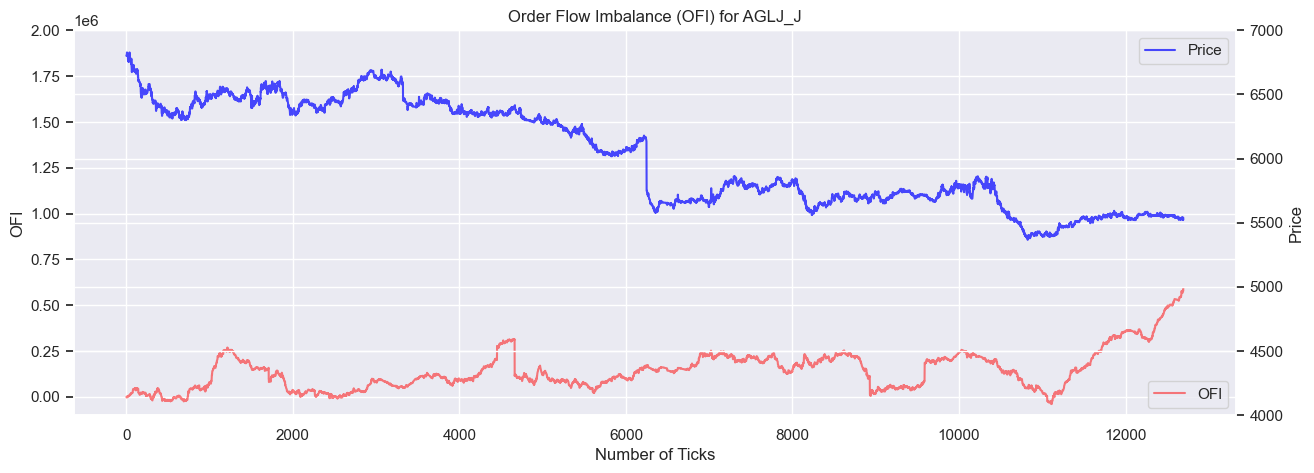



The Pearson correlation between the price and OFI is:  -0.45107451530143977


In [44]:
# Figure 6
signed_volume = aggr_dataset_2[aggr_dataset_2['Type'] == ' Trade']['Volume'] * aggr_dataset_2[aggr_dataset_2['Type'] == ' Trade']['Trade Sign'] # Calculate the OFI
ofi = signed_volume.cumsum() # Calculate the cumulative sum of the OFI
prices = aggr_dataset_2[aggr_dataset_2['Type'] == ' Trade']['Price'] # Get the prices

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(np.arange(len(ofi)), ofi, label = 'OFI', color = 'red', alpha = 0.5) # Plot the OFI
ax.set_ylabel('OFI')
ax.set_xlabel('Number of Ticks')
ax.set_title('Order Flow Imbalance (OFI) for AGLJ_J')
ax.set_ylim(-100000, 2000000)
ax.legend(loc = 'lower right')

ax2 = ax.twinx()
ax2.plot(np.arange(len(prices)), prices, color='blue', label='Price', alpha=0.7)
ax2.set_ylabel('Price')
ax2.legend()
ax2.set_ylim(4000, 7000)
plt.show()

print("\n\nThe Pearson correlation between the price and OFI is: ", np.corrcoef(prices, ofi)[0, 1]) # Calculate the Pearson correlation between the price and OFI

**Exercise 5**

Import the library `scipy` and compute the Spearman and Kendall correlation between the price and OFI. What do you see? Was that result what you expected?

The above result is somewhat counterintuitive and very common in practice. It highlights the importance of empirical analysis with real-world data rather than relying on only theoretical expectations.

As we can see, the price of AGLJ during these five days has a downward slope. On several occasions, the price has a short-term upward slope, but the trend in general is clear. Given the price, our expectation (based on theory and intuition) would be a downward slope for the OFI as well. But this is hardly the case since the OFI seems almost completely inconsistent with the price. The buying volume (as defined in this notebook) is rising which means that there are more buyers (takers) than sellers whereas, at the same time, the price is falling.

There could be several reasons for this phenomenon that could be very different if the data were retrieved from another exchange or for some other time interval:

* Market maker/Trader behavior: Market makers or large traders might be providing liquidity as prices fall, absorbing sell orders. This would show up as positive OFI (as they're buying) even as prices continue to decline.

* Large trades: A few large selling orders could outweigh the importance of many small buying orders.

* Market Microstructure Effects: In some market structures, large sell orders can trigger a series of smaller buy orders as they're filled, which could lead to this pattern.

* Time Frame Consideration: The relationship between OFI and price might be different over different time scales. What we're seeing could be a short-term effect that might reverse over longer periods.

**Exercise 6**

We deliberately gave a definition for buying and selling volume: Buying/Selling volume is the volume of the trades that were initiated by buyers/sellers (as takers). But now we must think of the buying and selling volume from the perspective of the trader's intention, which is the actual buying and selling volumes.

Hint: If a trader wants to buy, they can place a market order or a limit order.

Initiate a discussion in the forum with your ideas.


**Exercise 7**

We observed a counterintuitive result concerning the OFI of dataset (3): falling price with rising OFI. Now calculate the OFI for dataset (2) and plot it along with the price on the same graph (dual $y$-axis). What do you see?

Let's now provide ideas for plotting the best bid and ask along with the price of AGLJ: we will use the step function for the quote levels and the scatter for the price.

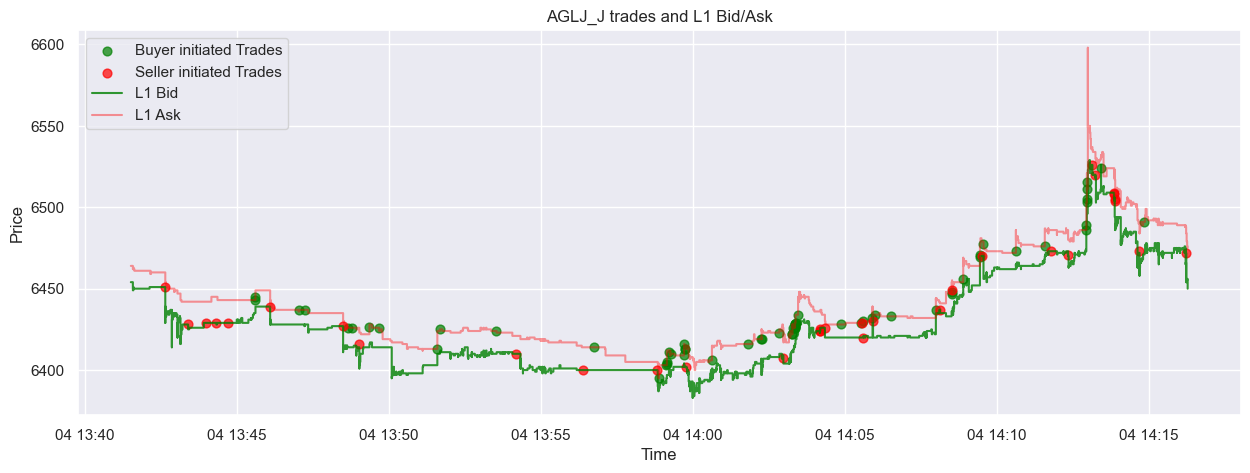

In [45]:
# Figure 7

zoomed_in_quotes_price = aggr_dataset_2.loc['2016-01-04'].iloc[15000:17000, :] # Slice the data

fig, ax = plt.subplots(figsize=(15, 5))

ax.scatter(x = zoomed_in_quotes_price[(zoomed_in_quotes_price['Type'] == ' Trade') & (zoomed_in_quotes_price['Trade Sign'] == 1)].index, \
              y = zoomed_in_quotes_price[(zoomed_in_quotes_price['Type'] == ' Trade') & (zoomed_in_quotes_price['Trade Sign'] == 1)]['Price'], color='green', \
                label='Buyer initiated Trades', alpha = 0.7, s = 40) # Plot the trades
ax.scatter(x = zoomed_in_quotes_price[(zoomed_in_quotes_price['Type'] == ' Trade') & (zoomed_in_quotes_price['Trade Sign'] == -1)].index, \
              y = zoomed_in_quotes_price[(zoomed_in_quotes_price['Type'] == ' Trade') & (zoomed_in_quotes_price['Trade Sign'] == -1)]['Price'], color='red', \
                label='Seller initiated Trades', alpha = 0.7, s = 40) # Plot the trades
ax.step(zoomed_in_quotes_price[zoomed_in_quotes_price['Type'] == ' Quote'].index, \
                zoomed_in_quotes_price[zoomed_in_quotes_price['Type'] == ' Quote']['L1 Bid'], color='green', \
                    label='L1 Bid', alpha = 0.8, where = 'post') # Plot the L1 Bid
ax.step(zoomed_in_quotes_price[zoomed_in_quotes_price['Type'] == ' Quote'].index, \
                zoomed_in_quotes_price[zoomed_in_quotes_price['Type'] == ' Quote']['L1 Ask'], color='red', \
                    label='L1 Ask', alpha = 0.4, where = 'post') # Plot the L1 Ask

ax.set_title("AGLJ_J trades and L1 Bid/Ask")
ax.set_xlabel("Time")
ax.set_ylabel("Price")
ax.legend()
plt.show()

**Exercise 8**

In Figure 7, you can see the plot of the best quotes plotted along the price. Do the following:
* Be certain you can explain the argument `where = 'post'` inside the step plot function.
* By checking the `matplotlib` documentation, enhance the above graph by adjusting the size of the scatter marker using the size of the trade. So, if trade A is larger than trade B, then marker A should be larger than marker B. You can choose a different date and slice of the dataset. Paste your results in the forum.

## **8. Resampling**

In the last section, we will be creating the time bars everyone is comfortable with. For this reason, we will use the `resample` method that works very well with a datetime index. We will create datasets for several timeframes and will showcase how some statistics change as the timeframe becomes larger. The dataset of our choice will be dataset (2): rvn_usdt.

In [46]:
rvn_usdt.resample('1min', label = 'right').agg({'price': 'ohlc', 'qty': 'sum'}).head()

price                                  qty
                        open     high      low    close       qty
timestamp                                                        
2023-04-01 00:01:00  0.02588  0.02594  0.02588  0.02594  270588.0
2023-04-01 00:02:00  0.02594  0.02596  0.02594  0.02596  354425.3
2023-04-01 00:03:00  0.02597  0.02600  0.02596  0.02599  423137.4
2023-04-01 00:04:00  0.02598  0.02598  0.02592  0.02593   96082.3
2023-04-01 00:05:00  0.02594  0.02594  0.02594  0.02594   42425.7

**Exercise 9**

Explain the argument `label = right`. Discuss your ideas in the forum. Also, find a suitable library to plot the 'candles' along with the volume.

In [47]:
#Create the resample function
def resample(df: pd.DataFrame, freq: str) -> pd.DataFrame:
    """
    Resample the data to a given frequency.
    """
    resampled_df = df.resample(freq, label = 'right').agg({'price': 'ohlc', 'qty': 'sum'}) # Resample the data
    resampled_df.columns = resampled_df.columns.droplevel(0) # Drop the first level of the columns. Create a simple column index instead of an Multiindex.
    return resampled_df

timeframes = ['1min', '2min', '5min', '10min', '15min', '30min', '1h', '2h', '4h', '8h', '12h', '1D', '2D', '5D'] # Define the timeframes

statistics = {} # Create a dictionary to store the statistics
for timeframe in timeframes:
    temp = resample(rvn_usdt, timeframe)['close'] # Resample the data
    temp_returns =  np.log(temp / temp.shift(1)).dropna() # Calculate the log returns
    statistics[timeframe] = {'mean': temp_returns.mean(), 'std': temp_returns.std(), 'skewness': temp_returns.skew(), 'kurt': temp_returns.kurt()} # Calculate the statistics

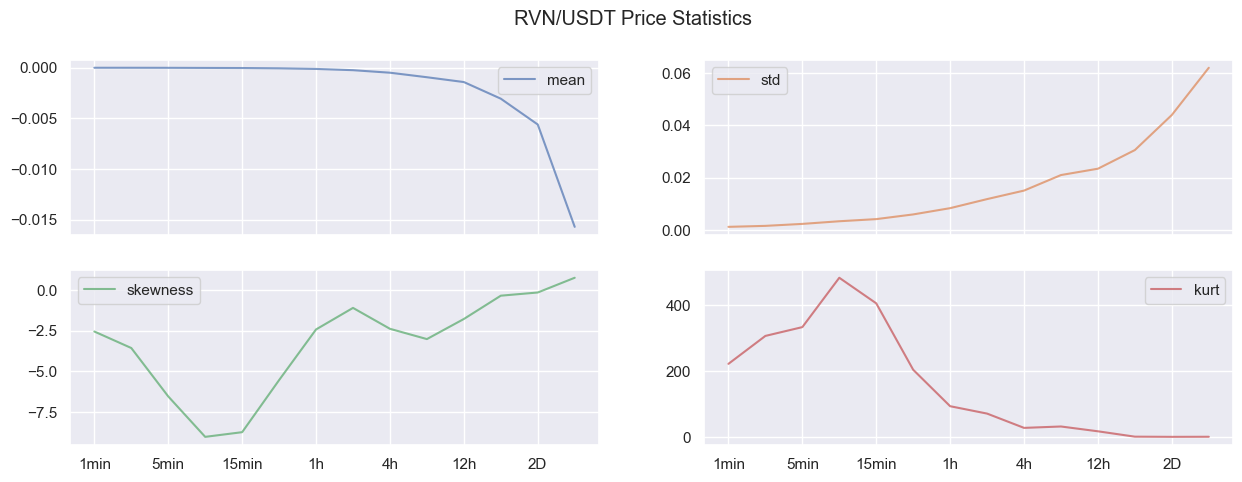

In [48]:
#Figure 8
pd.DataFrame(statistics).T.plot(subplots = True, figsize = (15, 5), layout = (2, 2), title = 'RVN/USDT Price Statistics', alpha = 0.7) # Plot the statistics
plt.show()

The above results are somehow expected and show us the properties that we lose or gain by aggregating the high-frequency data.

* The mean return is close to 0 for small timeframes. Since each trade corresponds to small price increments, it is natural that the price changes in small timeframes were not able to accumulate and show a mean different than zero.
    
    1) Microstructure Noise: At very high frequencies, returns are heavily influenced by market microstructure effects such as bid-ask bounce, which can mask any true price trend over short intervals.
    
    2) Martingale Property: In a fair market, price processes are often modeled as martingales, where the expected future price given all past information is the current price. This implies that expected short-term returns should be zero.

* Standard Deviation: The increase in standard deviation with larger timeframes is consistent with the properties of Brownian motion (more in the Derivative Pricing course), which are used to model price processes. Under the assumptions of Brownian Motion, variance scales linearly with time, so standard deviation scales with the square root of time.

* The slight upward slope in skewness as the timeframe gets larger could indicate that the positive price movements tend to be larger than the negative ones over longer periods.

* More importantly, the high kurtosis at small timeframes reflects the leptokurtic nature of high-frequency returns. More specifically:
    
    1) Fat Tails: The extreme events are common in leptokurtic distribution, more common in relation to the normal distribution.
    
    2) As we aggregate to the larger timeframes, the central limit theorem takes effect and the return distribution approaches normality. However, in larger timeframes, the returns still do not reach normality.

**Exercise 10**

Create time bars for the rvn_usdt pair as above but now include two more columns:
* A column named `buying_volume` that will consist of the aggregated volume of the trades attributed to the `is_buyer_maker = False`
* A column named `selling_volume` that will consist of the aggregated volume of the trades attributed to the `is_buyer_maker = True`

**Exercise 11**

In explaining the statistics of Figure 8, we used the central limit theorem to argue for the convergence of the returns distribution with the normal distribution. But we did not actually aggregate the returns. Rather, we used the `close` column of each timeframe to calculate the kurtosis. Is that argument used correctly or not? Why? Do the same as above but instead of the `close` price of each timeframe, calculate the `sum()` of the log returns. Does this change anything?

## **9. Conclusion**

This lesson has provided an introduction to tick data, its characteristics, and its importance in financial markets. We've explored the structure of tick-by-tick trade data and Level 1 data, demonstrating how to handle, clean, and plot these high-frequency datasets.

Key takeaways include:

1. The granularity of tick data provides insights into market microstructure that are not visible in lower-frequency data.

2. Cleaning is an essential preprocess step that should include the handling of split transactions and intra-second quotes (among others).

3. Order flow imbalance (OFI) can provide valuable insights into short-term market dynamics, but its interpretation requires careful consideration of market context and can be misleading.

4. Resampling tick data to various timeframes reveals how statistical properties of returns change with time aggregation, highlighting the trade-offs between granularity and noise.

5. Working with tick data presents unique challenges, including data volume, cleaning requirements, and the need for specialized analytical techniques.